This notebook explores the distributional properties of balance sheet targets and ratios, with a focus on scale, skewness, stability, and economic plausibility. No modeling is performed here.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = "../data/interim/balance_sheet_model_with_ratios.parquet"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (10, 4)


In [2]:
# Load main dataset
df = pd.read_parquet(DATA_PATH).copy()

# Parse date
if "end" in df.columns:
    df["end"] = pd.to_datetime(df["end"], errors="coerce")

print("Full df shape:", df.shape)
print("Min/Max end:", df["end"].min(), "->", df["end"].max())
display(df.head(3))

# Required columns
required = ["cik", "end", "y_Assets"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Train/Val/Test optional
train_path = "data/interim/train.parquet"
val_path   = "data/interim/val.parquet"
test_path  = "data/interim/test.parquet"

has_splits = all(os.path.exists(p) for p in [train_path, val_path, test_path])
print("Split files exist?", has_splits)

if has_splits:
    train = pd.read_parquet(train_path).copy()
    val   = pd.read_parquet(val_path).copy()
    test  = pd.read_parquet(test_path).copy()

    for d in [train, val, test]:
        d["end"] = pd.to_datetime(d["end"], errors="coerce")

    print("train/val/test shapes:", train.shape, val.shape, test.shape)
    df_work = train
    WORKING_SET = "train"
else:
    df_work = df
    WORKING_SET = "full"

print("Using df_work =", WORKING_SET, "shape:", df_work.shape)


Full df shape: (72575, 113)
Min/Max end: 2001-12-31 00:00:00 -> 2025-11-01 00:00:00


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax,Assets_lag1,AssetsCurrent_lag1,AssetsNoncurrent_lag1,Liabilities_lag1,LiabilitiesCurrent_lag1,LiabilitiesNoncurrent_lag1,StockholdersEquity_lag1,LiabilitiesAndStockholdersEquity_lag1,CashAndCashEquivalentsAtCarryingValue_lag1,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1,AccountsReceivableNetCurrent_lag1,InventoryNet_lag1,PrepaidExpenseCurrent_lag1,PropertyPlantAndEquipmentNet_lag1,Goodwill_lag1,IntangibleAssetsNetExcludingGoodwill_lag1,DebtCurrent_lag1,LongTermDebt_lag1,LongTermDebtCurrent_lag1,AccountsPayableCurrent_lag1,AccruedLiabilitiesCurrent_lag1,RetainedEarningsAccumulatedDeficit_lag1,CommonStockValue_lag1,AdditionalPaidInCapital_lag1,AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1,y_Assets,y_Assets_is_log,y_AssetsCurrent,y_AssetsCurrent_is_log,y_AssetsNoncurrent,y_AssetsNoncurrent_is_log,y_Liabilities,y_Liabilities_is_log,y_LiabilitiesCurrent,y_LiabilitiesCurrent_is_log,y_LiabilitiesNoncurrent,y_LiabilitiesNoncurrent_is_log,y_StockholdersEquity,y_StockholdersEquity_is_log,y_LiabilitiesAndStockholdersEquity,y_LiabilitiesAndStockholdersEquity_is_log,y_CashAndCashEquivalentsAtCarryingValue,y_CashAndCashEquivalentsAtCarryingValue_is_log,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log,y_AccountsReceivableNetCurrent,y_AccountsReceivableNetCurrent_is_log,y_InventoryNet,y_InventoryNet_is_log,y_PrepaidExpenseCurrent,y_PrepaidExpenseCurrent_is_log,y_PropertyPlantAndEquipmentNet,y_PropertyPlantAndEquipmentNet_is_log,y_Goodwill,y_Goodwill_is_log,y_IntangibleAssetsNetExcludingGoodwill,y_IntangibleAssetsNetExcludingGoodwill_is_log,y_DebtCurrent,y_DebtCurrent_is_log,y_LongTermDebt,y_LongTermDebt_is_log,y_LongTermDebtCurrent,y_LongTermDebtCurrent_is_log,y_AccountsPayableCurrent,y_AccountsPayableCurrent_is_log,y_AccruedLiabilitiesCurrent,y_AccruedLiabilitiesCurrent_is_log,y_RetainedEarningsAccumulatedDeficit,y_RetainedEarningsAccumulatedDeficit_is_log,y_CommonStockValue,y_CommonStockValue_is_log,y_AdditionalPaidInCapital,y_AdditionalPaidInCapital_is_log,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log,cash_to_assets,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity
0,0000001750,2025-02-28,2.859100e+09,1.534800e+09,NaN,NaN,545200000.0,1.131300e+09,NaN,2.859100e+09,84400000.0,100900000.0,NaN,775700000.0,NaN,153400000.0,528400000.0,223600000.0,NaN,NaN,NaN,278900000.0,236700000.0,9.354000e+08,45300000.0,NaN,-12100000.0,2.849300e+09,1.498000e+09,NaN,NaN,558300000.0,1.109400e+09,NaN,2.849300e+09,61700000.0,82500000.0,NaN,790000000.0,NaN,167000000.0,543200000.0,227300000.0,NaN,NaN,NaN,291800000.0,258800000.0,944300000.0,45300000.0,NaN,-10600000.0,0.003434,1,0.024269,1,NaN,0,NaN,0,-0.023744,1,0.019548,1,NaN,0,0.003434,1,0.313283,1,0.201332,1,NaN,0,-0.018267,1,NaN,0,-0.084945,1,-0.027624,1,-0.016412,1,NaN,0,NaN,0,NaN,0,-0.045215,1,-0.089262,1,-0.009470,1,0.0,1,NaN,0,-3.0,0,0.029520,0.536812,NaN,NaN,NaN,0.053653,0.184813,0.078206,0.346123,0.0,NaN
1,0000001750,2025-05-31,2.844600e+09,1.510600e+09,NaN,1.633000e+09,554700000.0,1.078300e+09,1.211600e+09,2.844600e+09,96500000.0,109200000.0,NaN,809200000.0,NaN,158500000.0,530800000.0,219600000.0,NaN,NaN,NaN,3031

Split files exist? False
Using df_work = full shape: (72575, 113)


In [3]:
y = df_work["y_Assets"]

print("y_Assets nulls:", y.isna().sum(), "/", len(y))
print("y_Assets <= 0 count:", (y <= 0).sum())
print("y_Assets == 0 count:", (y == 0).sum())
print("y_Assets negative count:", (y < 0).sum())

desc = y.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("y_Assets")
display(desc)

# Extra quantiles (more detailed)
qs = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
qvals = y.quantile(qs).to_frame("y_Assets_quantiles")
qvals.index = [f"q{int(q*1000)/10:g}%" for q in qs]  # e.g. q0.1%, q1%, q99.9%
display(qvals)


y_Assets nulls: 0 / 72575
y_Assets <= 0 count: 37080
y_Assets == 0 count: 2477
y_Assets negative count: 34603


,y_Assets
count,72575.000000
mean,0.042964
std,0.783412
min,-3.000000
1%,-3.000000
5%,-0.807964
50%,0.000000
95%,1.302723
99%,3.000000
max,3.000000


,y_Assets_quantiles
q0.1%,-3.000000
q1%,-3.000000
q5%,-0.807964
q25%,-0.061227
q50%,0.000000
q75%,0.056515
q95%,1.302723
q99%,3.000000
q99.9%,3.000000


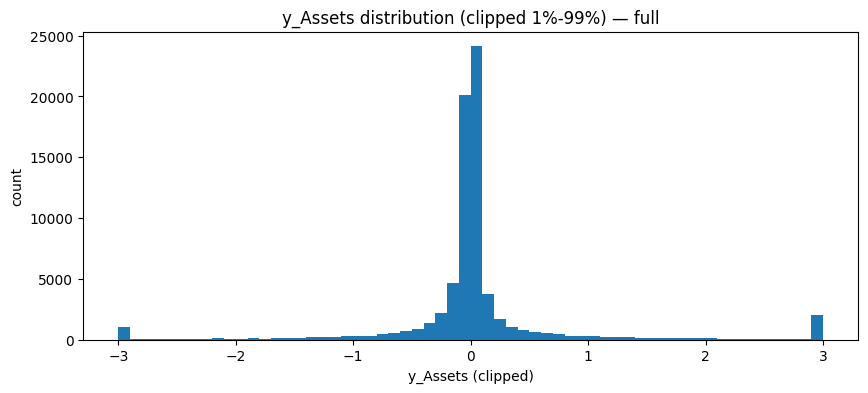

Plot clipping bounds:
1%: -3.0
99%: 3.0


In [4]:
y = df_work["y_Assets"].dropna()

# Winsorize for plotting only (1% to 99%)
lo, hi = y.quantile([0.01, 0.99])
y_clip = y.clip(lo, hi)

plt.figure()
plt.hist(y_clip, bins=60)
plt.title(f"y_Assets distribution (clipped 1%-99%) — {WORKING_SET}")
plt.xlabel("y_Assets (clipped)")
plt.ylabel("count")
plt.show()

print("Plot clipping bounds:")
print("1%:", lo)
print("99%:", hi)
